# Prediction Distribution Visualization (MLP Incremental Scaler)

This notebook evaluates only own-year pairs for `models_mlp_prevyears_monthly_features_incremental_scaler`.
For each year:
- best threshold is computed on that year's validation set (max F1 on PR curve),
- test set is evaluated using that threshold,
- predictions are visualized with two separate histograms split at threshold.

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

ROOT = Path('.')
SPLIT_PATH = ROOT / 'data_split.npz'
DATASET_PATH = ROOT / 'training_data_with_features_plus_monthly_indices.zarr'
MODELS_DIR = ROOT / 'models_mlp_prevyears_monthly_features_incremental_scaler'
EVAL_OUTPUT_DIR = ROOT / 'eval_outputs'
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_TEMPLATE = 'model_year_{year}_mlp_prevyears_monthly_features_incremental_scaler.pkl'
SCALER_TEMPLATE = 'scaler_year_{year}_mlp_prevyears_monthly_features_incremental_scaler.pkl'
DEFAULT_THRESHOLD = 0.5
DEFAULT_BINS_PER_HIST = 15

split = np.load(SPLIT_PATH)


def _first_existing_key(candidates):
    for key in candidates:
        if key in split.files:
            return key
    return None


train_key = _first_existing_key(['train_pixel_indices', 'train_idx', 'train_indices'])
val_key = _first_existing_key(['val_pixel_indices', 'valid_pixel_indices', 'val_idx', 'val_indices'])
test_key = _first_existing_key(['test_pixel_indices', 'test_idx', 'test_indices'])

if not all([train_key, val_key, test_key]):
    raise KeyError(f'Could not resolve split keys from: {split.files}')

train_pixel_indices = split[train_key]
val_pixel_indices = split[val_key]
test_pixel_indices = split[test_key]

ds = xr.open_zarr(DATASET_PATH)
year_to_idx = {int(year): idx for idx, year in enumerate(ds.year.values)}


def infer_years_from_models(models_dir, model_template):
    years = []
    for year in range(2010, 2035):
        if (models_dir / model_template.format(year=year)).exists():
            years.append(year)
    return years


def load_model(year):
    path = MODELS_DIR / MODEL_TEMPLATE.format(year=year)
    if not path.exists():
        return None
    with open(path, 'rb') as file:
        return pickle.load(file)


def load_scaler(year):
    path = MODELS_DIR / SCALER_TEMPLATE.format(year=year)
    if not path.exists():
        return None
    with open(path, 'rb') as file:
        return pickle.load(file)


def _prepare_features_common(
    ds,
    pixel_indices,
    year_idx,
    scaler=None,
    scaler_mode='auto',
    include_last_year=True,
    include_monthly=False,
):
    if year_idx == 0:
        return np.empty((0, 0)), np.empty((0,)), scaler

    valid_scaler_modes = {'auto', 'fit', 'partial_fit', 'transform', 'none'}
    if scaler_mode not in valid_scaler_modes:
        raise ValueError(f'Invalid scaler_mode: {scaler_mode}')

    s2_all_years = ds['s2_bands'].isel(pixel=pixel_indices).values
    s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)

    ds_subset = ds.isel(pixel=pixel_indices, year=year_idx)
    s2_features = ds_subset['s2_bands'].values
    if np.isnan(s2_features).any():
        s2_features = np.where(np.isnan(s2_features), s2_mean_per_pixel, s2_features)

    dem_features = ds_subset['dem'].values.reshape(-1, 1)
    ndvi_features = ds_subset['ndvi'].values.reshape(-1, 1)
    ndwi_features = ds_subset['ndwi'].values.reshape(-1, 1)

    features_list = [s2_features, dem_features, ndvi_features, ndwi_features]

    if include_last_year:
        ds_prev = ds.isel(pixel=pixel_indices, year=year_idx - 1)
        ndvi_last_year = np.where(np.isnan(ds_prev['ndvi'].values.reshape(-1, 1)), 0, ds_prev['ndvi'].values.reshape(-1, 1))
        ndwi_last_year = np.where(np.isnan(ds_prev['ndwi'].values.reshape(-1, 1)), 0, ds_prev['ndwi'].values.reshape(-1, 1))
        features_list.extend([ndvi_last_year, ndwi_last_year])

        required_last_year_bands = ['B04', 'B03', 'B06']
        band_to_idx = {band: i for i, band in enumerate(ds['s2_band'].values)}
        missing_bands = [band for band in required_last_year_bands if band not in band_to_idx]
        if missing_bands:
            raise ValueError(f'Missing required S2 bands for last-year features: {missing_bands}')

        for band in required_last_year_bands:
            band_values = ds_prev['s2_bands'].sel(s2_band=band).values
            band_values = np.where(np.isnan(band_values), 0, band_values)
            features_list.append(band_values.reshape(-1, 1))

    if 'nbr' in ds.data_vars:
        features_list.append(ds_subset['nbr'].values.reshape(-1, 1))

    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:
        delta_year_idx = year_idx - 1
        ds_delta = ds.isel(pixel=pixel_indices, year=delta_year_idx)
        features_list.append(ds_delta['ndvi_delta'].values.reshape(-1, 1))
        features_list.append(ds_delta['ndwi_delta'].values.reshape(-1, 1))
        if 'nbr_delta' in ds.data_vars:
            features_list.append(ds_delta['nbr_delta'].values.reshape(-1, 1))

    for var_name in ['years_since_last_disturbance', 'log_years_since_last_disturbance', 'ever_disturbed']:
        if var_name in ds.data_vars:
            features_list.append(ds_subset[var_name].values.reshape(-1, 1))

    if include_monthly:
        yearly_index_feature_names = [
            'ndvi_cv_year',
            'ndvi_max_m2m_drop_year',
            'ndvi_max_year',
            'ndvi_min_year',
            'ndvi_std_year',
            'ndwi_cv_year',
            'ndwi_max_m2m_drop_year',
            'ndwi_max_year',
            'ndwi_min_year',
            'ndwi_std_year',
        ]
        for feature_name in yearly_index_feature_names:
            if feature_name in ds.data_vars:
                features_list.append(ds_subset[feature_name].values.reshape(-1, 1))

    X = np.concatenate(features_list, axis=1)
    y = ds_subset['disturbances'].values

    valid_label_mask = np.isin(y, [0, 1])
    X = X[valid_label_mask]
    y = y[valid_label_mask]

    nan_mask = ~np.isnan(X).any(axis=1)
    X = X[nan_mask]
    y = y[nan_mask]

    if len(X) == 0:
        return np.empty((0, 0)), np.empty((0,)), scaler

    if scaler_mode == 'none':
        return X, y, scaler

    if scaler is None:
        scaler = StandardScaler()

    if scaler_mode == 'auto':
        if hasattr(scaler, 'n_features_in_'):
            X = scaler.transform(X)
        else:
            X = scaler.fit_transform(X)
    elif scaler_mode == 'fit':
        X = scaler.fit_transform(X)
    elif scaler_mode == 'partial_fit':
        scaler.partial_fit(X)
        X = scaler.transform(X)
    elif scaler_mode == 'transform':
        if not hasattr(scaler, 'n_features_in_'):
            raise ValueError("Scaler must be fitted before scaler_mode='transform'.")
        X = scaler.transform(X)

    return X, y, scaler


def prepare_features_monthly(ds, pixel_indices, year_idx, scaler=None, scaler_mode='auto'):
    return _prepare_features_common(
        ds=ds,
        pixel_indices=pixel_indices,
        year_idx=year_idx,
        scaler=scaler,
        scaler_mode=scaler_mode,
        include_last_year=True,
        include_monthly=True,
    )


def compute_metrics(y_true, y_pred, y_proba):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': np.nan,
        'pr_auc': np.nan,
    }
    if len(np.unique(y_true)) > 1:
        out['roc_auc'] = roc_auc_score(y_true, y_proba)
        out['pr_auc'] = average_precision_score(y_true, y_proba)
    return out


def best_f1_threshold(y_true, y_score, default_threshold=0.5):
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float(default_threshold), {
            'source': 'fallback',
            'reason': 'insufficient classes',
            'n_val_samples': int(len(y_true)),
        }

    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return float(default_threshold), {
            'source': 'fallback',
            'reason': 'no thresholds',
            'n_val_samples': int(len(y_true)),
        }

    f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
    best_idx = int(np.argmax(f1_vals[:-1])) if len(f1_vals) > 1 else 0
    threshold = float(thresholds[min(best_idx, len(thresholds) - 1)])
    return threshold, {
        'source': 'computed_pr_f1',
        'reason': 'max F1 on validation PR curve',
        'n_val_samples': int(len(y_true)),
    }


years = infer_years_from_models(MODELS_DIR, MODEL_TEMPLATE)
if not years:
    raise RuntimeError(f'No model files found in {MODELS_DIR.resolve()}')

print(f'Loaded splits from {SPLIT_PATH.name}')
print(f'  train: {len(train_pixel_indices):,} | val: {len(val_pixel_indices):,} | test: {len(test_pixel_indices):,}')
print(f'Using years from model files: {years}')

Loaded splits from data_split.npz
  train: 5,597,776 | val: 1,273,437 | test: 1,283,992
Using years from model files: [2017, 2018, 2019, 2020, 2021, 2022]


In [2]:
def evaluate_own_year(model_year, default_threshold=DEFAULT_THRESHOLD):
    if model_year not in year_to_idx:
        return None

    model_obj = load_model(model_year)
    scaler_obj = load_scaler(model_year)
    if model_obj is None or scaler_obj is None:
        return None

    year_idx = year_to_idx[model_year]

    X_val, y_val, _ = prepare_features_monthly(
        ds,
        val_pixel_indices,
        year_idx,
        scaler=scaler_obj,
        scaler_mode='transform',
    )

    if len(X_val) == 0:
        threshold = float(default_threshold)
        threshold_meta = {
            'source': 'fallback',
            'reason': 'empty validation set',
            'n_val_samples': 0,
        }
    else:
        y_val_proba = model_obj.predict_proba(X_val)[:, 1]
        threshold, threshold_meta = best_f1_threshold(y_val, y_val_proba, default_threshold=default_threshold)

    X_test, y_test, _ = prepare_features_monthly(
        ds,
        test_pixel_indices,
        year_idx,
        scaler=scaler_obj,
        scaler_mode='transform',
    )

    if len(X_test) == 0:
        return None

    y_test_proba = model_obj.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= threshold).astype(int)

    metrics = compute_metrics(y_test, y_test_pred, y_test_proba)

    row = {
        'model_year': int(model_year),
        'eval_year': int(model_year),
        'threshold_used': float(threshold),
        'threshold_source': threshold_meta.get('source', 'unknown'),
        'threshold_reason': threshold_meta.get('reason', ''),
        'n_val_samples': int(threshold_meta.get('n_val_samples', len(y_val))),
        'n_test_samples': int(len(y_test)),
        **metrics,
    }

    return row, y_test_proba, y_test_pred, y_test


rows = []
predictions_by_year = {}

for year in years:
    output = evaluate_own_year(year)
    if output is None:
        print(f'Skipped year {year}: missing data/model/scaler or empty test set')
        continue

    row, y_proba, y_pred, y_true = output
    rows.append(row)
    predictions_by_year[year] = {
        'y_proba': y_proba,
        'y_pred': y_pred,
        'y_true': y_true,
        'threshold': row['threshold_used'],
    }

results_df = pd.DataFrame(rows).sort_values('model_year').reset_index(drop=True)

if results_df.empty:
    raise RuntimeError('No own-year evaluation results were produced.')

results_csv = EVAL_OUTPUT_DIR / 'mlp_incremental_scaler_own_year_evaluation.csv'
results_json = EVAL_OUTPUT_DIR / 'mlp_incremental_scaler_own_year_evaluation.json'
results_df.to_csv(results_csv, index=False)
results_df.to_json(results_json, orient='records', indent=2)

print('Own-year evaluation complete')
print(f'Saved: {results_csv}')
print(f'Saved: {results_json}')
display(results_df)

C:\Users\bartu\AppData\Local\Temp\ipykernel_10552\2003748368.py:99: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)
C:\Users\bartu\AppData\Local\Temp\ipykernel_10552\2003748368.py:99: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)
C:\Users\bartu\AppData\Local\Temp\ipykernel_10552\2003748368.py:99: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)
C:\Users\bartu\AppData\Local\Temp\ipykernel_10552\2003748368.py:99: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)
C:\Users\bartu\AppData\Local\Temp\ipykernel_10552\2003748368.py:99: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)
C:\Users\bartu\AppData\Local\Temp\ipykernel_10552\2003748368.py:99: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)
C:\Users\bartu\AppData\Local\Temp\ipykernel_10

Own-year evaluation complete
Saved: eval_outputs\mlp_incremental_scaler_own_year_evaluation.csv
Saved: eval_outputs\mlp_incremental_scaler_own_year_evaluation.json


,model_year,eval_year,threshold_used,threshold_source,threshold_reason,n_val_samples,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,2017,0.892193,computed_pr_f1,max F1 on validation PR curve,1270825,1278700,0.971450,0.247403,0.281524,0.263363,0.864627,0.203730
1,2018,2018,0.907633,computed_pr_f1,max F1 on validation PR curve,1271706,1281398,0.977416,0.495505,0.412582,0.450257,0.910150,0.444538
2,2019,2019,0.902265,computed_pr_f1,max F1 on validation PR curve,1271570,1281008,0.979487,0.503608,0.438074,0.468561,0.896262,0.425024
3,2020,2020,0.946095,computed_pr_f1,max F1 on validation PR curve,1271629,1281489,0.977580,0.554315,0.433144,0.486295,0.905983,0.454080
4,2021,2021,0.917529,computed_pr_f1,max F1 on validation PR curve,1271639,1281313,0.984276,0.545610,0.413675,0.470570,0.909478,0.440404
5,2022,2022,0.903504,computed_pr_f1,max F1 on validation PR curve,1272609,1282452,0.965782,0.459774,0.487325,0.473149,0.908581,0.454931


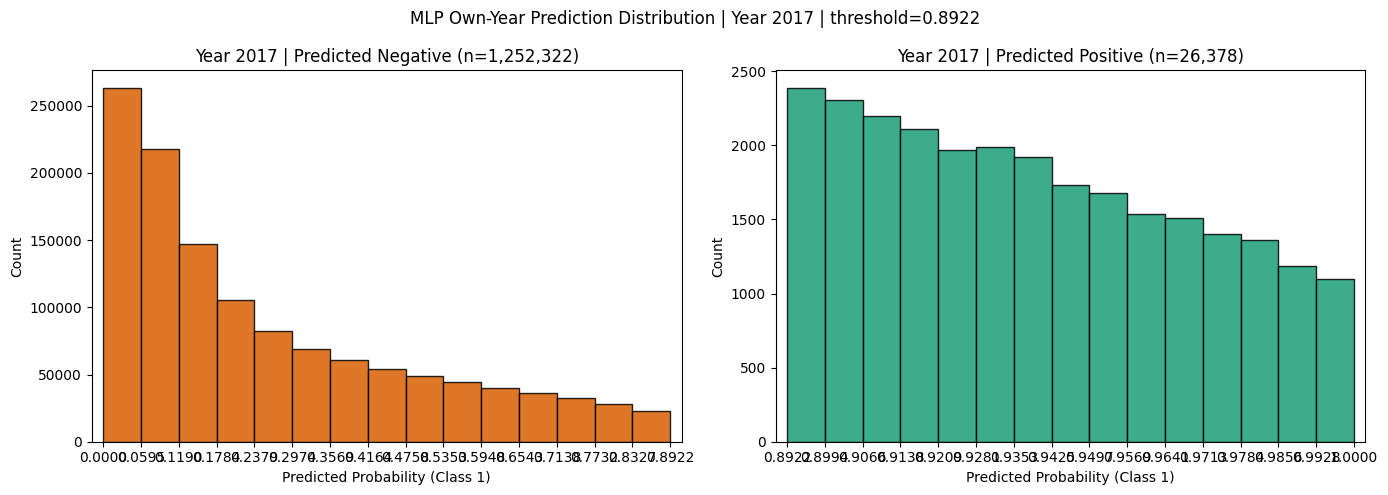

Saved: eval_outputs\mlp_incremental_scaler_own_year_threshold_split_hist_year_2017.png


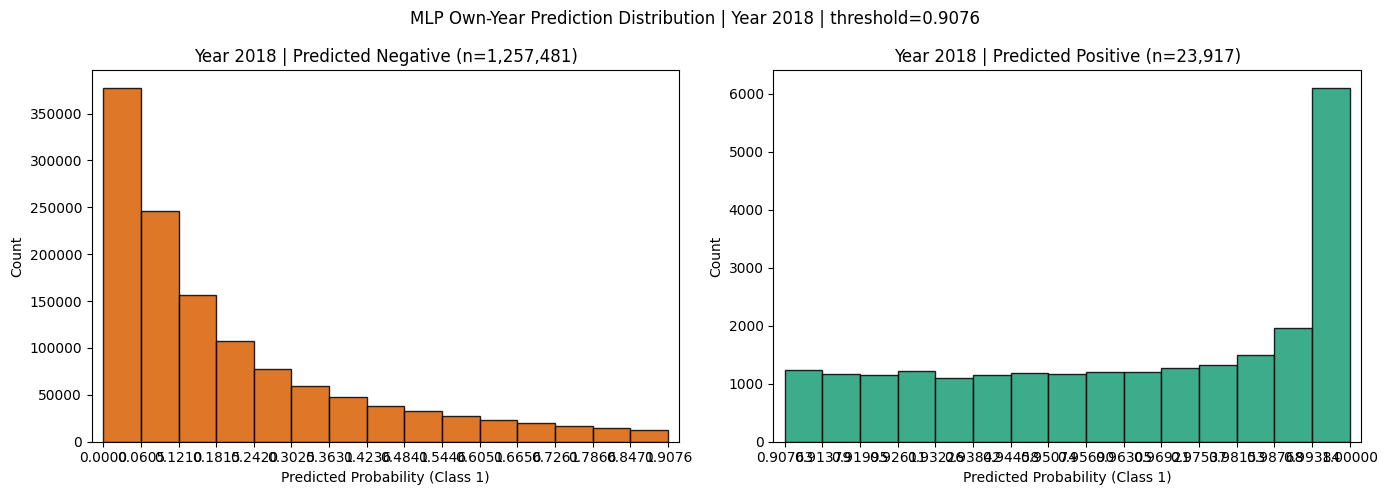

Saved: eval_outputs\mlp_incremental_scaler_own_year_threshold_split_hist_year_2018.png


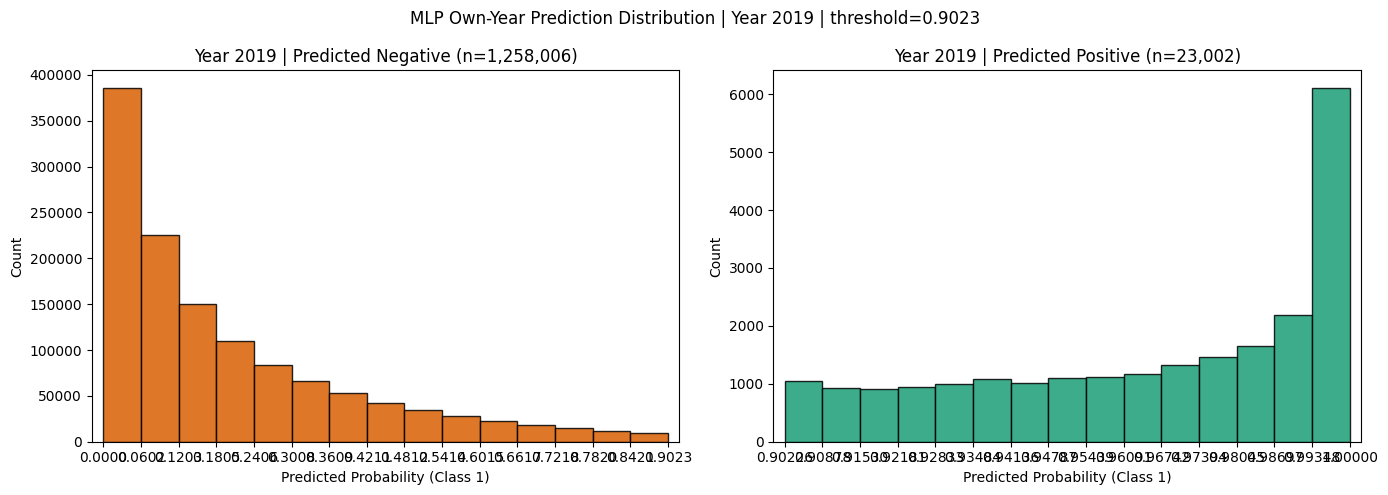

Saved: eval_outputs\mlp_incremental_scaler_own_year_threshold_split_hist_year_2019.png


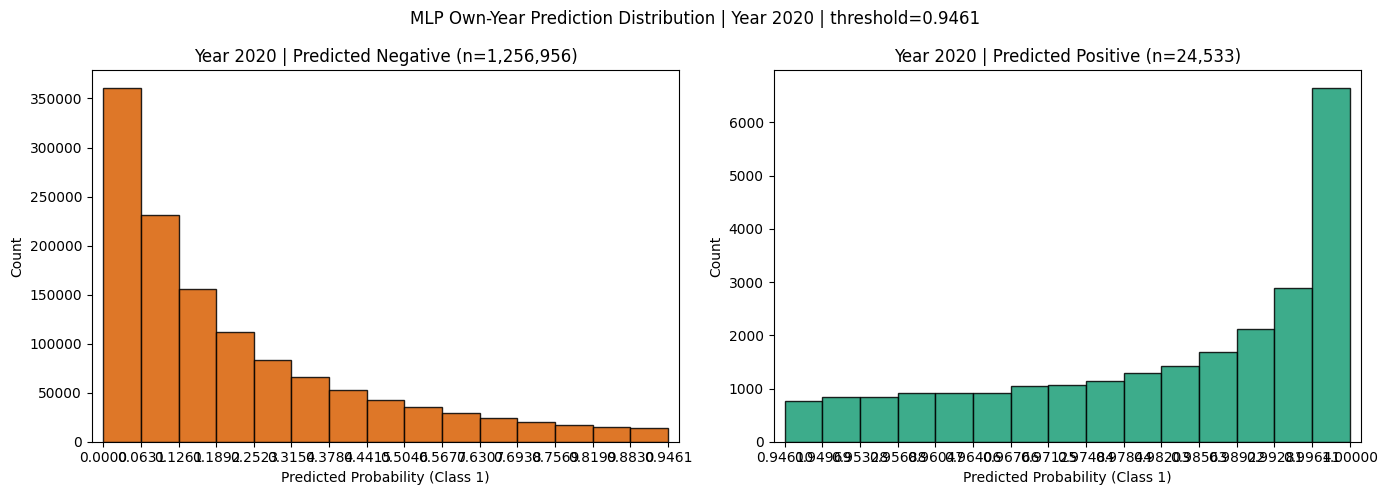

Saved: eval_outputs\mlp_incremental_scaler_own_year_threshold_split_hist_year_2020.png


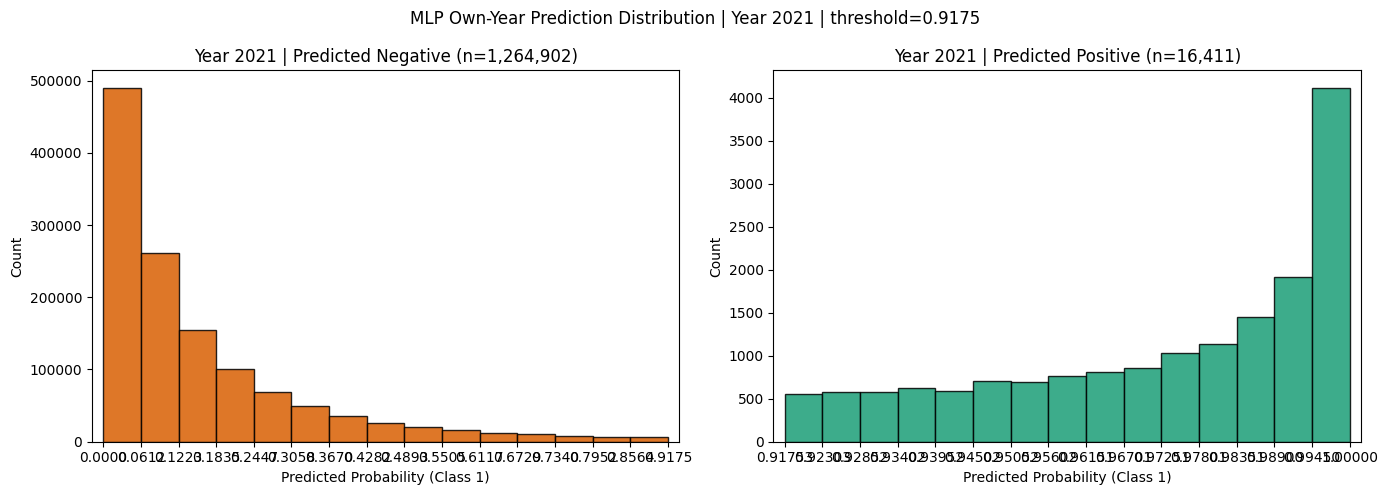

Saved: eval_outputs\mlp_incremental_scaler_own_year_threshold_split_hist_year_2021.png


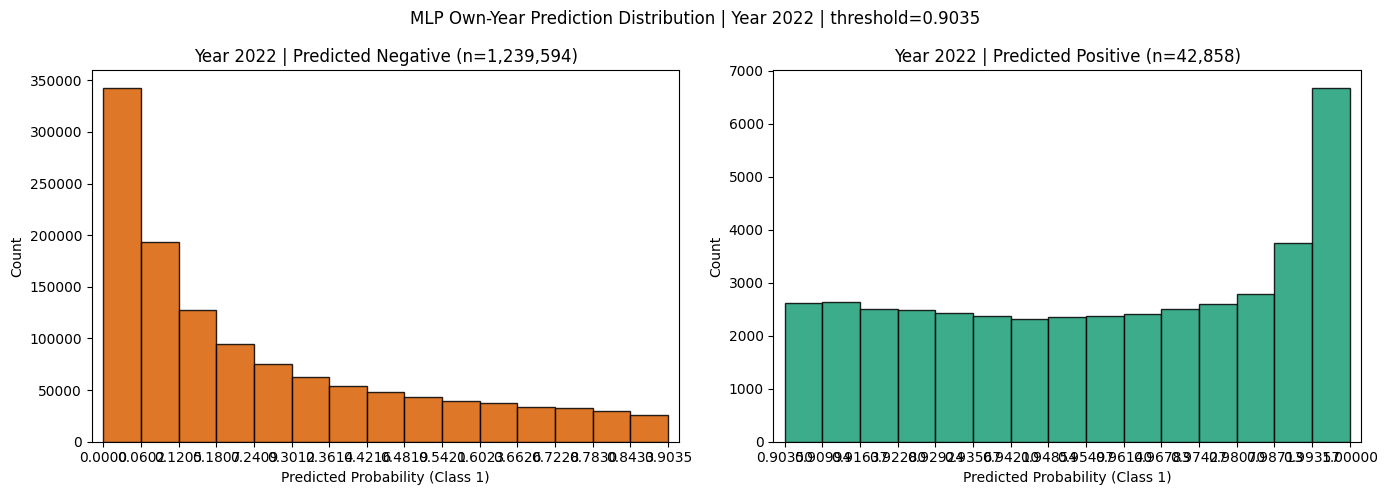

Saved: eval_outputs\mlp_incremental_scaler_own_year_threshold_split_hist_year_2022.png


,year,total_predictions,neg_count,pos_count,partition_ok
0,2017,1278700,1252322,26378,True
1,2018,1281398,1257481,23917,True
2,2019,1281008,1258006,23002,True
3,2020,1281489,1256956,24533,True
4,2021,1281313,1264902,16411,True
5,2022,1282452,1239594,42858,True


In [3]:
def _threshold_split_bins(threshold, n_bins=10, eps=1e-9):
    threshold = float(np.clip(threshold, 0.0, 1.0))

    if threshold <= 0.0:
        neg_bins = np.linspace(0.0, eps, n_bins + 1)
    else:
        neg_bins = np.linspace(0.0, threshold, n_bins + 1)

    if threshold >= 1.0:
        pos_bins = np.linspace(1.0 - eps, 1.0, n_bins + 1)
    else:
        pos_bins = np.linspace(threshold, 1.0, n_bins + 1)

    return neg_bins, pos_bins


def plot_threshold_split_histograms_for_year(year, payload, n_bins=DEFAULT_BINS_PER_HIST):
    y_proba = payload['y_proba']
    y_pred = payload['y_pred']
    threshold = float(payload['threshold'])

    neg_scores = y_proba[y_pred == 0]
    pos_scores = y_proba[y_pred == 1]

    neg_bins, pos_bins = _threshold_split_bins(threshold, n_bins=n_bins)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    axes[0].hist(neg_scores, bins=neg_bins, color='#d95f02', alpha=0.85, edgecolor='black')
    axes[0].set_title(f'Year {year} | Predicted Negative (n={len(neg_scores):,})')
    axes[0].set_xlabel('Predicted Probability (Class 1)')
    axes[0].set_ylabel('Count')
    axes[0].set_xticks(neg_bins)
    neg_padding = (neg_bins[-1] - neg_bins[0]) * 0.02
    axes[0].set_xlim(neg_bins[0] - neg_padding, neg_bins[-1] + neg_padding)

    axes[1].hist(pos_scores, bins=pos_bins, color='#1b9e77', alpha=0.85, edgecolor='black')
    axes[1].set_title(f'Year {year} | Predicted Positive (n={len(pos_scores):,})')
    axes[1].set_xlabel('Predicted Probability (Class 1)')
    axes[1].set_ylabel('Count')
    axes[1].set_xticks(pos_bins)
    pos_padding = (pos_bins[-1] - pos_bins[0]) * 0.02
    axes[1].set_xlim(pos_bins[0] - pos_padding, pos_bins[-1] + pos_padding)

    fig.suptitle(f'MLP Own-Year Prediction Distribution | Year {year} | threshold={threshold:.4f}')
    fig.tight_layout()
    return fig


for year in sorted(predictions_by_year):
    fig = plot_threshold_split_histograms_for_year(year, predictions_by_year[year], n_bins=DEFAULT_BINS_PER_HIST)
    out_path = EVAL_OUTPUT_DIR / f'mlp_incremental_scaler_own_year_threshold_split_hist_year_{year}.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')


# Optional integrity check: partition sizes should sum to total predictions for each year.
integrity_rows = []
for year, payload in sorted(predictions_by_year.items()):
    y_pred = payload['y_pred']
    total = int(len(y_pred))
    neg_count = int(np.sum(y_pred == 0))
    pos_count = int(np.sum(y_pred == 1))
    integrity_rows.append({
        'year': year,
        'total_predictions': total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'partition_ok': bool(total == (neg_count + pos_count)),
    })

integrity_df = pd.DataFrame(integrity_rows)
display(integrity_df)

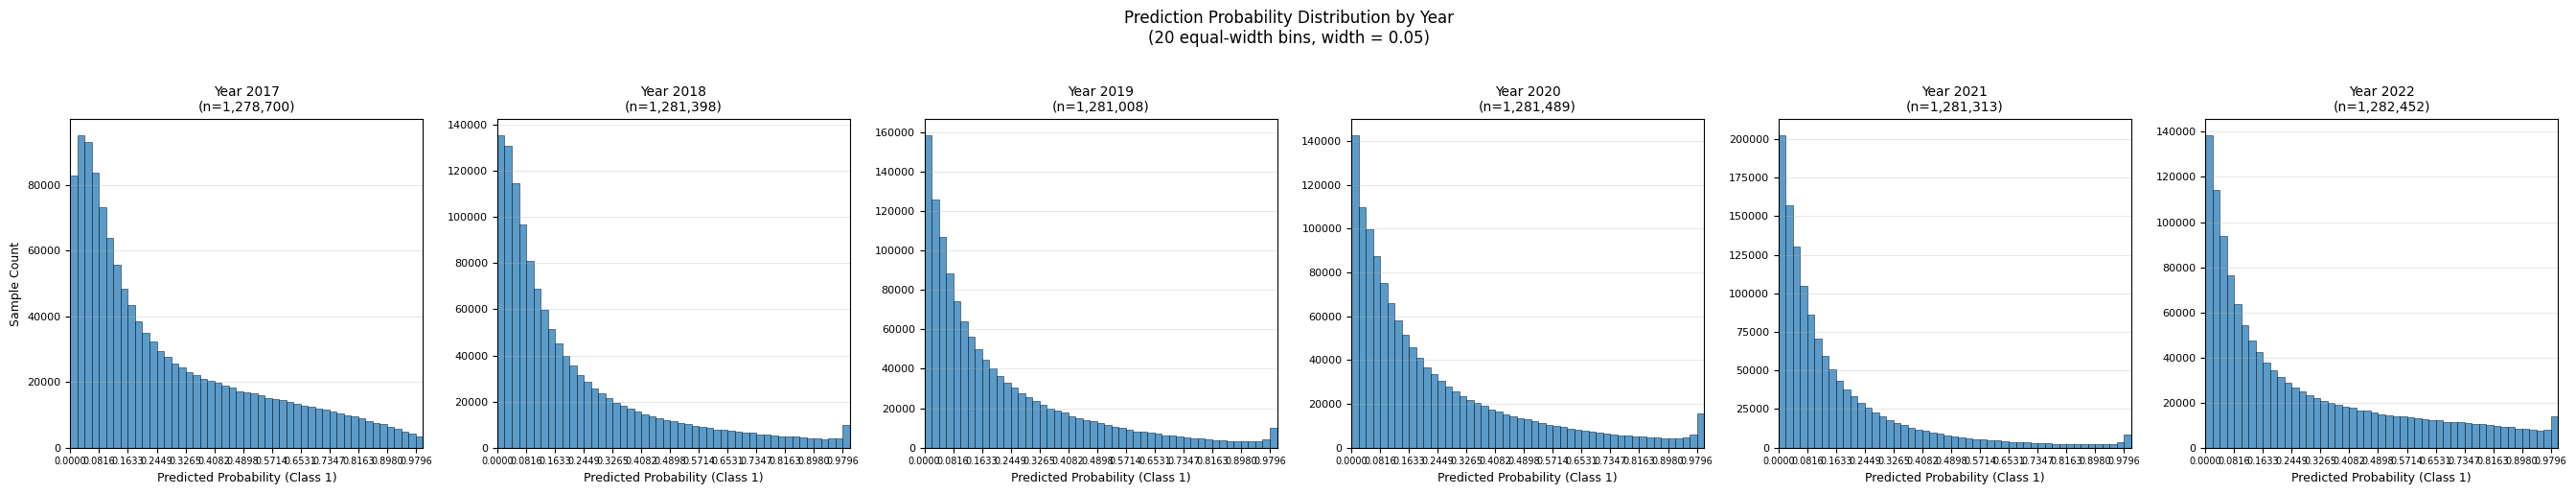

Saved: eval_outputs\mlp_incremental_scaler_own_year_probability_hist_by_year.png


In [8]:
# Per-year prediction probability histograms
# 20 equal-width bins (0.05 width) spanning [0, 1]
PROB_BINS = np.linspace(0, 1, 50)  # 20 intervals

years_sorted = sorted(predictions_by_year)
n_years = len(years_sorted)

fig, axes = plt.subplots(1, n_years, figsize=(4.5 * n_years, 5), sharey=False)
if n_years == 1:
    axes = [axes]

for idx, year in enumerate(years_sorted):
    y_proba = predictions_by_year[year]['y_proba']
    ax = axes[idx]

    ax.hist(y_proba, bins=PROB_BINS, color='#3182bd', alpha=0.80, edgecolor='black', linewidth=0.4)
    ax.set_title(f'Year {year}\n(n={len(y_proba):,})', fontsize=10)
    ax.set_xlabel('Predicted Probability (Class 1)', fontsize=9)
    if idx == 0:
        ax.set_ylabel('Sample Count', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xticks(PROB_BINS[::4])  # tick every 0.20 to avoid crowding
    ax.xaxis.set_tick_params(labelsize=7)
    ax.yaxis.set_tick_params(labelsize=8)
    ax.yaxis.get_major_formatter().set_scientific(False)
    ax.grid(True, axis='y', alpha=0.35, linewidth=0.6)

fig.suptitle(
    'Prediction Probability Distribution by Year\n'
    '(20 equal-width bins, width = 0.05)',
    fontsize=12, y=1.02
)
fig.tight_layout()

out_path = EVAL_OUTPUT_DIR / 'mlp_incremental_scaler_own_year_probability_hist_by_year.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## Percentile Analysis of Classification Probabilities

For each model year, percentiles of the predicted class-1 probabilities are computed across five groups:
- **all** — full test set
- **pred_neg** — samples predicted as negative (score < threshold)
- **pred_pos** — samples predicted as positive (score ≥ threshold)
- **true_neg** — ground-truth negative samples
- **true_pos** — ground-truth positive samples

In [5]:
PERCENTILE_LEVELS = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_col_names = [f'p{p}' for p in PERCENTILE_LEVELS]

pct_rows = []
for year in sorted(predictions_by_year):
    payload = predictions_by_year[year]
    y_proba_yr = payload['y_proba']
    y_pred_yr  = payload['y_pred']
    y_true_yr  = payload['y_true']
    threshold  = float(payload['threshold'])

    groups = {
        'all':      y_proba_yr,
        'pred_neg': y_proba_yr[y_pred_yr == 0],
        'pred_pos': y_proba_yr[y_pred_yr == 1],
        'true_neg': y_proba_yr[y_true_yr == 0],
        'true_pos': y_proba_yr[y_true_yr == 1],
    }

    for group_name, arr in groups.items():
        if len(arr) == 0:
            pcts = [float('nan')] * len(PERCENTILE_LEVELS)
        else:
            pcts = np.percentile(arr, PERCENTILE_LEVELS).tolist()

        pct_rows.append({
            'year': year,
            'group': group_name,
            'n': len(arr),
            'threshold': threshold,
            **dict(zip(pct_col_names, pcts)),
        })

pct_df = pd.DataFrame(pct_rows)

pct_csv = EVAL_OUTPUT_DIR / 'mlp_incremental_scaler_own_year_percentiles.csv'
pct_df.to_csv(pct_csv, index=False)
print(f'Saved: {pct_csv}')

display(pct_df.to_string(index=False))

Saved: eval_outputs\mlp_incremental_scaler_own_year_percentiles.csv


' year    group       n  threshold           p1       p5      p10      p25      p50      p75      p90      p95      p99\n 2017      all 1278700   0.892193 4.491833e-14 0.016054 0.030278 0.072811 0.183923 0.429741 0.681795 0.799629 0.937641\n 2017 pred_neg 1252322   0.892193 3.613803e-14 0.015742 0.029715 0.071169 0.177422 0.409373 0.643971 0.749633 0.857818\n 2017 pred_pos   26378   0.892193 8.930557e-01 0.895989 0.900122 0.912689 0.936227 0.963875 0.983654 0.991451 0.997421\n 2017 true_neg 1255519   0.892193 3.741301e-14 0.015791 0.029805 0.071460 0.178830 0.416190 0.662713 0.779773 0.919289\n 2017 true_pos   23181   0.892193 5.187256e-02 0.159412 0.269470 0.507477 0.752347 0.908672 0.974102 0.988831 0.997099\n 2018      all 1281398   0.907633 4.651837e-07 0.008539 0.019275 0.050028 0.126641 0.299191 0.566710 0.740066 0.965620\n 2018 pred_neg 1257481   0.907633 4.343570e-07 0.008295 0.018927 0.048975 0.122806 0.283873 0.523225 0.669633 0.846713\n 2018 pred_pos   23917   0.907633 9.088

In [6]:
### Percentile Visualization

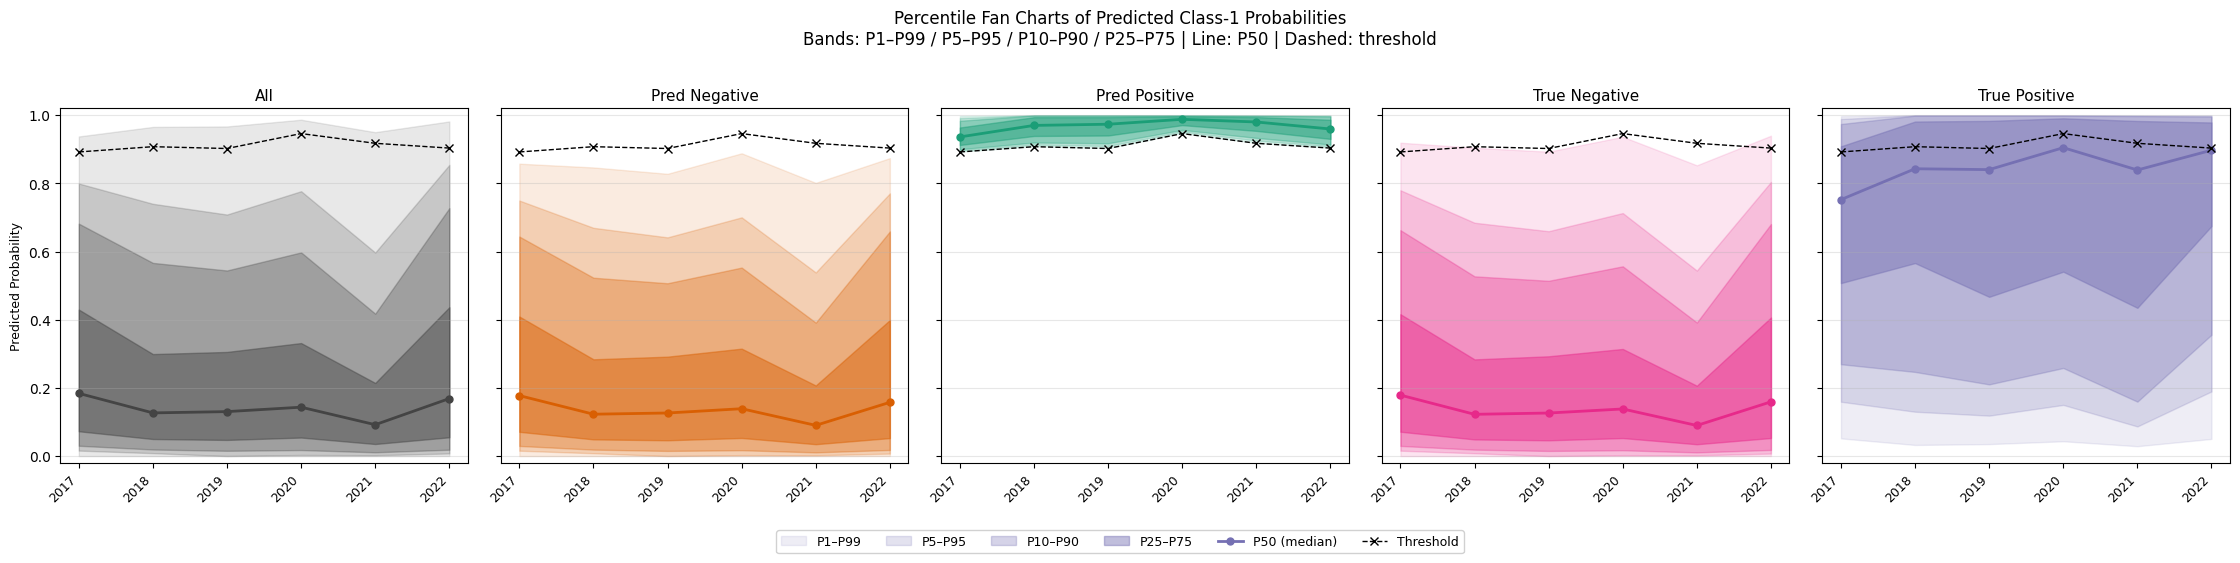

Saved: eval_outputs\mlp_incremental_scaler_percentile_fan_charts.png


In [7]:
BAND_PAIRS = [
    ('p1',  'p99', 0.12),
    ('p5',  'p95', 0.20),
    ('p10', 'p90', 0.30),
    ('p25', 'p75', 0.45),
]
MEDIAN_COL = 'p50'

GROUP_COLORS = {
    'all':      '#444444',
    'pred_neg': '#d95f02',
    'pred_pos': '#1b9e77',
    'true_neg': '#e7298a',
    'true_pos': '#7570b3',
}
GROUP_LABELS = {
    'all':      'All',
    'pred_neg': 'Pred Negative',
    'pred_pos': 'Pred Positive',
    'true_neg': 'True Negative',
    'true_pos': 'True Positive',
}

groups_to_plot = ['all', 'pred_neg', 'pred_pos', 'true_neg', 'true_pos']
years_sorted = sorted(pct_df['year'].unique())
x = np.arange(len(years_sorted))
x_labels = [str(y) for y in years_sorted]

fig, axes = plt.subplots(1, len(groups_to_plot), figsize=(4.5 * len(groups_to_plot), 5), sharey=True)

for col_idx, group in enumerate(groups_to_plot):
    ax = axes[col_idx]
    color = GROUP_COLORS[group]
    group_data = pct_df[pct_df['group'] == group].set_index('year').reindex(years_sorted)

    # filled bands — widest to narrowest
    for lo_col, hi_col, alpha in BAND_PAIRS:
        lo = group_data[lo_col].values.astype(float)
        hi = group_data[hi_col].values.astype(float)
        label = f'{lo_col.upper()}–{hi_col.upper()}'
        ax.fill_between(x, lo, hi, alpha=alpha, color=color, label=label)

    # median line
    med = group_data[MEDIAN_COL].values.astype(float)
    ax.plot(x, med, color=color, linewidth=2.0, marker='o', markersize=5,
            zorder=5, label='P50 (median)')

    # threshold markers
    thresholds = group_data['threshold'].values.astype(float)
    ax.plot(x, thresholds, color='black', linewidth=1.0, linestyle='--',
            marker='x', markersize=6, zorder=6, label='Threshold')

    ax.set_title(GROUP_LABELS[group], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel('Predicted Probability' if col_idx == 0 else '', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

# legend from the last subplot
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(handles),
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.08))

fig.suptitle(
    'Percentile Fan Charts of Predicted Class-1 Probabilities\n'
    'Bands: P1–P99 / P5–P95 / P10–P90 / P25–P75 | Line: P50 | Dashed: threshold',
    fontsize=12, y=1.02,
)
fig.tight_layout()
out = EVAL_OUTPUT_DIR / 'mlp_incremental_scaler_percentile_fan_charts.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')